#Comparative Analysis of Robust Invisible Watermarking Techniques for AI-Generated Images


## Section 0 — Environment Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q datasets huggingface_hub scikit-image opencv-python-headless gradio tqdm

In [ ]:
import os
import glob
import json
import shutil
import zipfile
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

print(f"torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch: 2.11.0+cu128
CUDA available: True
Device: NVIDIA L4
Using device: cuda


In [ ]:
PROJECT_ROOT = '/content/drive/MyDrive/AuthentiMark'

WIPE_EXISTING = False

if WIPE_EXISTING and os.path.exists(PROJECT_ROOT):
    shutil.rmtree(PROJECT_ROOT)
    print(f"Wiped existing project folder: {PROJECT_ROOT}")
else:
    print(f"Keeping existing project folder (WIPE_EXISTING={WIPE_EXISTING})")

for sub in ['data/raw/images', 'data/cleaned', 'data/splits',
            'checkpoints/ae', 'checkpoints/vae', 'checkpoints/gan', 'checkpoints/detector',
            'outputs/watermarked_images', 'outputs/results']:
    os.makedirs(os.path.join(PROJECT_ROOT, sub), exist_ok=True)

Keeping existing project folder (WIPE_EXISTING=False)


In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Global seed set to {SEED}")

Global seed set to 42


## Section 1 — Dataset Preparation

### 1a. Load Dataset & Explore

In [ ]:
SAMPLE_SIZE = 15000

RAW_DIR = os.path.join(PROJECT_ROOT, 'data/raw')
RAW_IMG_DIR = os.path.join(RAW_DIR, 'images')
RAW_META_PATH = os.path.join(RAW_DIR, 'metadata.csv')
os.makedirs(RAW_IMG_DIR, exist_ok=True)

existing_images = glob.glob(os.path.join(RAW_IMG_DIR, '*.webp'))

if len(existing_images) >= SAMPLE_SIZE and os.path.exists(RAW_META_PATH):
    print(f"Found {len(existing_images)} images already on Drive at {RAW_IMG_DIR} -> loading from Drive")
    meta_df = pd.read_csv(RAW_META_PATH)
    source = "Drive"
else:
    print(f"Drive raw folder incomplete ({len(existing_images)} images found, need {SAMPLE_SIZE}) -> downloading from HuggingFace")
    from huggingface_hub import hf_hub_download

    records = []
    num_parts_needed = (SAMPLE_SIZE // 1000) + 1

    for part_num in range(1, num_parts_needed + 1):
        zip_filename = f'part-{part_num:06d}.zip'
        zip_path = hf_hub_download(repo_id='poloclub/diffusiondb', filename=zip_filename,
                                    subfolder='diffusiondb-large-part-1', repo_type='dataset')

        extract_dir = os.path.join(RAW_DIR, f'tmp_extract_{part_num}')
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(extract_dir)

        json_path = os.path.join(extract_dir, f'part-{part_num:06d}.json')
        with open(json_path) as f:
            part_meta = json.load(f)

        for fname, meta in part_meta.items():
            src_path = os.path.join(extract_dir, fname)
            dst_path = os.path.join(RAW_IMG_DIR, fname)
            if os.path.exists(src_path):
                shutil.move(src_path, dst_path)
                with Image.open(dst_path) as im:
                    w, h = im.size
                records.append({
                    'image_id': fname,
                    'prompt': meta.get('p', ''),
                    'width': w,
                    'height': h,
                })

        shutil.rmtree(extract_dir, ignore_errors=True)
        print(f"Part {part_num}/{num_parts_needed} done, total images so far: {len(records)}")

        if len(records) >= SAMPLE_SIZE:
            break

    meta_df = pd.DataFrame(records).head(SAMPLE_SIZE)
    meta_df.to_csv(RAW_META_PATH, index=False)
    print(f"Saved {len(meta_df)} images + metadata to {RAW_DIR} (only needs to happen once)")
    source = "HuggingFace (direct part download)"

if len(meta_df) > SAMPLE_SIZE:
    meta_df = meta_df.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
    print(f"Subsampled down to {SAMPLE_SIZE} images (seed={SEED})")

print(f"\nData source used: {source}")
print(f"Total images: {len(meta_df)}")

Drive raw folder incomplete (564 images found, need 15000) -> downloading from HuggingFace


diffusiondb-large-part-1/part-000001.zip: reconstructing file:   0%|          |  0.00B /  528MB            

diffusiondb-large-part-1/part-000001.zip: downloading bytes:           |  0.00B            

Part 1/16 done, total images so far: 1000


diffusiondb-large-part-1/part-000002.zip: reconstructing file:   0%|          |  0.00B /  512MB            

...

diffusiondb-large-part-1/part-000014.zip: downloading bytes:           |  0.00B            

Part 14/16 done, total images so far: 14000


diffusiondb-large-part-1/part-000015.zip: reconstructing file:   0%|          |  0.00B /  442MB            

diffusiondb-large-part-1/part-000015.zip: downloading bytes:           |  0.00B            

Part 15/16 done, total images so far: 15000
Saved 15000 images + metadata to /content/drive/MyDrive/AuthentiMark/data/raw (only needs to happen once)

Data source used: HuggingFace (direct part download)
Total images: 15000


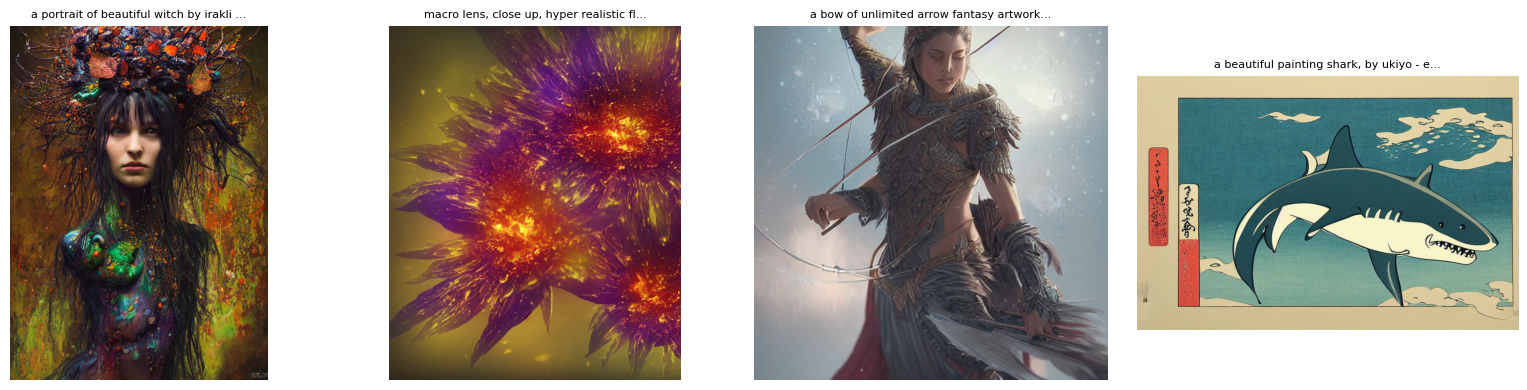

              width        height
count  15000.000000  15000.000000
mean     604.394667    610.483200
std      172.424803    148.075561
min      320.000000    320.000000
25%      512.000000    512.000000
50%      512.000000    512.000000
75%      704.000000    704.000000
max     1536.000000   1280.000000

Prompt length (chars) stats:
count    15000.000000
mean       164.075200
std         92.615507
min          0.000000
25%         85.000000
50%        157.000000
75%        242.000000
max        426.000000
Name: prompt, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sample_rows = meta_df.sample(4, random_state=SEED)
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img = Image.open(os.path.join(RAW_IMG_DIR, row['image_id']))
    ax.imshow(img)
    ax.set_title(row['prompt'][:40] + '...' if len(row['prompt']) > 40 else row['prompt'], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(meta_df[['width', 'height']].describe())
print(f"\nPrompt length (chars) stats:")
print(meta_df['prompt'].str.len().describe())

### 1b. Cleaning

In [ ]:
def is_readable(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

n_before = len(meta_df)
readable_mask = meta_df['image_id'].apply(lambda f: is_readable(os.path.join(RAW_IMG_DIR, f)))
removed_corrupted = int(n_before - readable_mask.sum())
clean_df = meta_df[readable_mask].copy()

MIN_SIDE, MAX_SIDE = 64, 1024
size_mask = (clean_df['width'] >= MIN_SIDE) & (clean_df['width'] <= MAX_SIDE) & \
            (clean_df['height'] >= MIN_SIDE) & (clean_df['height'] <= MAX_SIDE)
removed_outlier_res = int(len(clean_df) - size_mask.sum())
clean_df = clean_df[size_mask].copy()

dup_mask = clean_df.duplicated(subset='image_id')
removed_dupes = int(dup_mask.sum())
clean_df = clean_df[~dup_mask].copy()

CLEANED_DIR = os.path.join(PROJECT_ROOT, 'data/cleaned')
CLEANED_META_PATH = os.path.join(CLEANED_DIR, 'metadata.csv')
os.makedirs(CLEANED_DIR, exist_ok=True)
clean_df.to_csv(CLEANED_META_PATH, index=False)

print(f"Before cleaning: {n_before}")
print(f"Removed (corrupted/unreadable): {removed_corrupted}")
print(f"Removed (outlier resolution, outside [{MIN_SIDE},{MAX_SIDE}]): {removed_outlier_res}")
print(f"Removed (duplicate image_id): {removed_dupes}")
print(f"After cleaning: {len(clean_df)}")

Before cleaning: 15000
Removed (corrupted/unreadable): 0
Removed (outlier resolution, outside [64,1024]): 428
Removed (duplicate image_id): 0
After cleaning: 14572


### 1c. Preprocessing & Splits

In [ ]:
IMG_SIZE = 128

shuffled_ids = clean_df['image_id'].sample(frac=1.0, random_state=SEED).tolist()
n = len(shuffled_ids)
n_train = int(n * 0.7)
n_val = int(n * 0.1)

train_ids = shuffled_ids[:n_train]
val_ids = shuffled_ids[n_train:n_train + n_val]
test_ids = shuffled_ids[n_train + n_val:]

splits = {'train': train_ids, 'val': val_ids, 'test': test_ids}

SPLITS_DIR = os.path.join(PROJECT_ROOT, 'data/splits')
os.makedirs(SPLITS_DIR, exist_ok=True)
with open(os.path.join(SPLITS_DIR, 'splits.json'), 'w') as f:
    json.dump(splits, f)

overlap_tv = set(train_ids) & set(val_ids)
overlap_tt = set(train_ids) & set(test_ids)
overlap_vt = set(val_ids) & set(test_ids)

print(f"Image resolution target: {IMG_SIZE}x{IMG_SIZE}")
print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")
print(f"Leakage check -> train/val: {len(overlap_tv)}, train/test: {len(overlap_tt)}, val/test: {len(overlap_vt)}")

Image resolution target: 128x128
Train: 10200 | Val: 1457 | Test: 2915
Leakage check -> train/val: 0, train/test: 0, val/test: 0


### 1d. Feature Engineering

In [ ]:
MESSAGE_LEN = 32

rng = np.random.RandomState(SEED)
manifest = {}
for split_name, split_ids in splits.items():
    for image_id in split_ids:
        bits = rng.randint(0, 2, size=MESSAGE_LEN).tolist()
        manifest[image_id] = {'split': split_name, 'message': bits}

MANIFEST_PATH = os.path.join(SPLITS_DIR, 'manifest.json')
with open(MANIFEST_PATH, 'w') as f:
    json.dump(manifest, f)

print(f"Generated {MESSAGE_LEN}-bit watermark messages for {len(manifest)} images (seed={SEED})")
print(f"Manifest saved to {MANIFEST_PATH}")
print("Example entry:", list(manifest.items())[0])

print("\n=== Dataset pipeline complete ===")
print(f"Images: {len(clean_df)} | Train/Val/Test: {len(train_ids)}/{len(val_ids)}/{len(test_ids)} | "
      f"Resolution: {IMG_SIZE}x{IMG_SIZE} | Message length: {MESSAGE_LEN} bits")

Generated 32-bit watermark messages for 14572 images (seed=42)
Manifest saved to /content/drive/MyDrive/AuthentiMark/data/splits/manifest.json
Example entry: ('9ec4853d-223d-42cf-b00e-1cdd282873c6.webp', {'split': 'train', 'message': [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]})

=== Dataset pipeline complete ===
Images: 14572 | Train/Val/Test: 10200/1457/2915 | Resolution: 128x128 | Message length: 32 bits


## Section 2 — Autoencoder (AE)

### 2a. Architecture (draft only, shape check)

Two fixes vs. the previous attempt:
- The encoder's residual embedding strength is increased and no longer aggressively dampened,
  giving the message a real chance to survive into the output image.
- The decoder replaces global average pooling (which discarded the fine-grained spatial signal
  needed to tell 32 different bit patterns apart) with a flatten + linear head that preserves
  spatial detail.

In [ ]:
class WatermarkImageDataset(Dataset):
    def __init__(self, image_ids, img_dir, manifest, img_size):
        self.image_ids = image_ids
        self.img_dir = img_dir
        self.manifest = manifest
        self.img_size = img_size

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img = Image.open(os.path.join(self.img_dir, image_id)).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img_t = torch.from_numpy(np.array(img, dtype=np.float32) / 255.0).permute(2, 0, 1)
        message = torch.tensor(self.manifest[image_id]['message'], dtype=torch.float32)
        return img_t, message, image_id


class AEEncoder(nn.Module):
    def __init__(self, message_len, img_size, residual_scale=0.3):
        super().__init__()
        self.message_len = message_len
        self.img_size = img_size
        self.residual_scale = residual_scale
        self.msg_fc = nn.Linear(message_len, img_size * img_size)

        self.net = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1), nn.Tanh(),
        )

    def forward(self, image, message):
        b = image.size(0)
        msg_map = self.msg_fc(message).view(b, 1, self.img_size, self.img_size)
        x = torch.cat([image, msg_map], dim=1)
        residual = self.net(x)
        watermarked = torch.clamp(image + self.residual_scale * residual, 0.0, 1.0)
        return watermarked


class AEDecoder(nn.Module):
    def __init__(self, message_len, img_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        reduced = img_size // 16
        self.flatten_dim = 128 * reduced * reduced
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, message_len),
        )

    def forward(self, image):
        x = self.net(image)
        x = x.flatten(1)
        return self.fc(x)

In [ ]:
with open(os.path.join(SPLITS_DIR, 'manifest.json')) as f:
    manifest = json.load(f)

train_ds = WatermarkImageDataset(train_ids, RAW_IMG_DIR, manifest, IMG_SIZE)
val_ds = WatermarkImageDataset(val_ids, RAW_IMG_DIR, manifest, IMG_SIZE)
test_ds = WatermarkImageDataset(test_ids, RAW_IMG_DIR, manifest, IMG_SIZE)

_draft_encoder = AEEncoder(MESSAGE_LEN, IMG_SIZE).to(device)
_draft_decoder = AEDecoder(MESSAGE_LEN, IMG_SIZE).to(device)

sample_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
imgs, msgs, ids = next(iter(sample_loader))
imgs, msgs = imgs.to(device), msgs.to(device)

with torch.no_grad():
    wm_imgs = _draft_encoder(imgs, msgs)
    recovered_logits = _draft_decoder(wm_imgs)

print(f"Input images: {tuple(imgs.shape)}")
print(f"Input messages: {tuple(msgs.shape)}")
print(f"Watermarked images: {tuple(wm_imgs.shape)}")
print(f"Recovered message logits: {tuple(recovered_logits.shape)}")
assert wm_imgs.shape == imgs.shape
assert recovered_logits.shape == msgs.shape
print("Shape check passed -- AE architecture draft OK (no training yet)")

del _draft_encoder, _draft_decoder

Input images: (4, 3, 128, 128)
Input messages: (4, 32)
Watermarked images: (4, 3, 128, 128)
Recovered message logits: (4, 32)
Shape check passed -- AE architecture draft OK (no training yet)


### 2b. Training

In [ ]:
AE_BATCH_SIZE = 16
AE_CKPT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints/ae')
AE_CKPT_PATH = os.path.join(AE_CKPT_DIR, 'ae_latest.pt')

ae_encoder = AEEncoder(MESSAGE_LEN, IMG_SIZE).to(device)
ae_decoder = AEDecoder(MESSAGE_LEN, IMG_SIZE).to(device)

if not os.path.exists(AE_CKPT_PATH):
    raise FileNotFoundError(f"No trained AE checkpoint found at {AE_CKPT_PATH}. Train the AE before running this cell.")

ckpt = torch.load(AE_CKPT_PATH, map_location=device)
ae_encoder.load_state_dict(ckpt['encoder'])
ae_decoder.load_state_dict(ckpt['decoder'])
ae_encoder.eval()
ae_decoder.eval()
history = ckpt['history']

train_loader = DataLoader(train_ds, batch_size=AE_BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=AE_BATCH_SIZE, shuffle=False, num_workers=2)

def evaluate_bit_accuracy(encoder, decoder, loader):
    encoder.eval(); decoder.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, msgs, _ in loader:
            imgs, msgs = imgs.to(device), msgs.to(device)
            wm = encoder(imgs, msgs)
            logits = decoder(wm)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == msgs).sum().item()
            total += msgs.numel()
    return correct / total

print(f"Loaded trained AE from {AE_CKPT_PATH}")
print(f"Trained for {ckpt['epoch']} epochs")
print(f"Final val bit accuracy: {history['val_bit_acc'][-1]:.4f}")

Loaded trained AE from /content/drive/MyDrive/AuthentiMark/checkpoints/ae/ae_latest.pt
Trained for 60 epochs
Final val bit accuracy: 0.9996


### 2c. Results — Loss Curves & Before/After Comparison

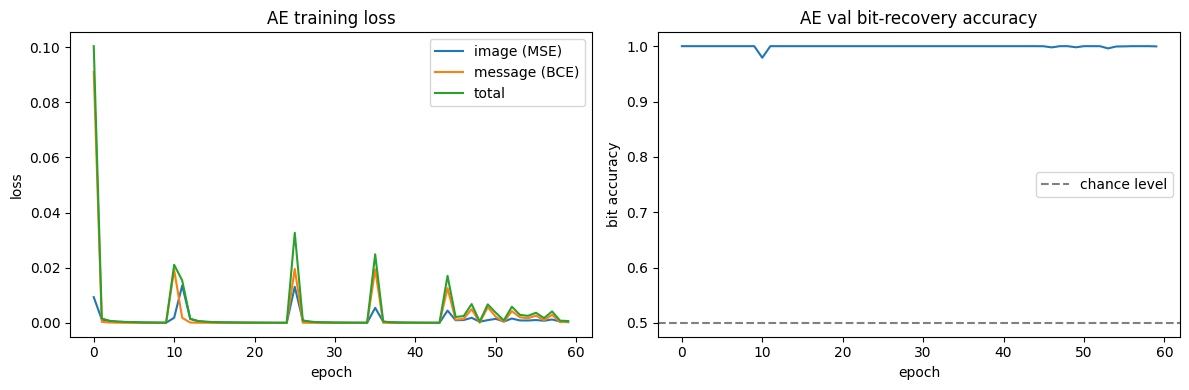

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['image_loss'], label='image (MSE)')
axes[0].plot(history['message_loss'], label='message (BCE)')
axes[0].plot(history['total_loss'], label='total')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].set_title('AE training loss')

axes[1].plot(history['val_bit_acc'])
axes[1].axhline(0.5, color='gray', linestyle='--', label='chance level')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('bit accuracy'); axes[1].set_title('AE val bit-recovery accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

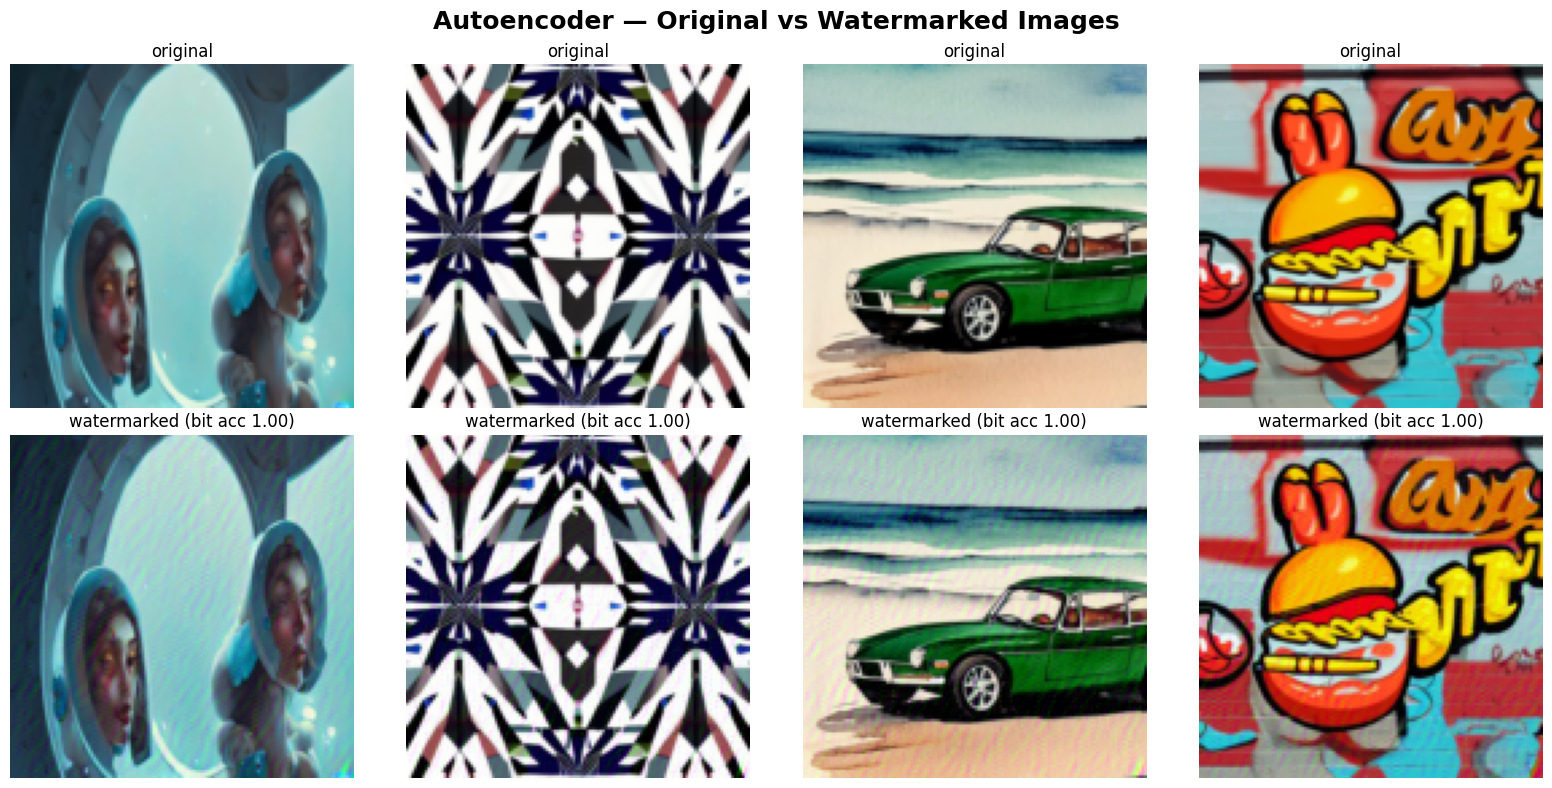

AEDecoder(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=32, bias=True)
  )
)

In [ ]:
ae_encoder.eval()
ae_decoder.eval()
imgs, msgs, ids = next(iter(val_loader))
imgs, msgs = imgs.to(device), msgs.to(device)

with torch.no_grad():
    watermarked = ae_encoder(imgs, msgs)
    logits = ae_decoder(watermarked)
    preds = (torch.sigmoid(logits) > 0.5).float()
    bit_acc_batch = (preds == msgs).float().mean(dim=1)

n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
fig.suptitle('Autoencoder — Original vs Watermarked Images', fontsize=18, fontweight='bold')
for i in range(n_show):
    orig = imgs[i].cpu().permute(1, 2, 0).numpy()
    wm = watermarked[i].cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig); axes[0, i].set_title('original'); axes[0, i].axis('off')
    axes[1, i].imshow(wm); axes[1, i].set_title(f'watermarked (bit acc {bit_acc_batch[i]:.2f})'); axes[1, i].axis('off')
plt.tight_layout()
plt.show()

ae_encoder.train()
ae_decoder.train()

## Section 3 — VAE
Reuse the AE structure with a reparameterized latent (mu, sigma) and a
KL-divergence term, plus a variant that watermarks Stable Diffusion's own internal VAE latent.

VAE watermark encoder-decoder. Same overall task as the AE (embed a 32-bit message
invisibly, recover it later) but with a regularized, sampled latent space (reparameterization
trick + KL-divergence term), which should generalize better and embed more robustly than the
plain AE's fixed deterministic mapping.

### 3a. Architecture

Same overall shape as the AE — an encoder embeds the message into the image, a decoder reads
it back out. The difference: the encoder's message pathway now outputs a mean and log-variance
(mu, logvar) instead of a single fixed value, and we sample from that distribution using the
reparameterization trick, with a KL-divergence term pulling it toward a standard normal. This
should give a smoother, more structured embedding space than the plain AE.

In [ ]:
class VAEEncoder(nn.Module):
    def __init__(self, message_len, img_size, residual_scale=0.3, latent_channels=64):
        super().__init__()
        self.message_len = message_len
        self.img_size = img_size
        self.residual_scale = residual_scale
        self.latent_channels = latent_channels

        self.msg_fc = nn.Linear(message_len, img_size * img_size)

        self.trunk = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.mu_head = nn.Conv2d(64, latent_channels, 3, padding=1)
        self.logvar_head = nn.Conv2d(64, latent_channels, 3, padding=1)
        nn.init.zeros_(self.logvar_head.weight)
        nn.init.constant_(self.logvar_head.bias, -6.0)

        self.decode_trunk = nn.Sequential(
            nn.Conv2d(latent_channels, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, 3, padding=1), nn.Tanh(),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, image, message):
        b = image.size(0)
        msg_map = self.msg_fc(message).view(b, 1, self.img_size, self.img_size)
        x = torch.cat([image, msg_map], dim=1)

        features = self.trunk(x)
        mu = self.mu_head(features)
        logvar = self.logvar_head(features)
        z = self.reparameterize(mu, logvar)

        residual = self.decode_trunk(z)
        watermarked = torch.clamp(image + self.residual_scale * residual, 0.0, 1.0)
        return watermarked, mu, logvar

In [ ]:
class VAEDecoder(nn.Module):
    def __init__(self, message_len, img_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        reduced = img_size // 16
        self.flatten_dim = 128 * reduced * reduced
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, message_len),
        )

    def forward(self, image):
        x = self.net(image)
        x = x.flatten(1)
        return self.fc(x)

In [ ]:
_draft_vae_encoder = VAEEncoder(MESSAGE_LEN, IMG_SIZE).to(device)
_draft_vae_decoder = VAEDecoder(MESSAGE_LEN, IMG_SIZE).to(device)

sample_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
imgs, msgs, ids = next(iter(sample_loader))
imgs, msgs = imgs.to(device), msgs.to(device)

with torch.no_grad():
    wm_imgs, mu, logvar = _draft_vae_encoder(imgs, msgs)
    recovered_logits = _draft_vae_decoder(wm_imgs)

print(f"Input images: {tuple(imgs.shape)}")
print(f"Input messages: {tuple(msgs.shape)}")
print(f"Watermarked images: {tuple(wm_imgs.shape)}")
print(f"Latent mu: {tuple(mu.shape)}, logvar: {tuple(logvar.shape)}")
print(f"Recovered message logits: {tuple(recovered_logits.shape)}")
assert wm_imgs.shape == imgs.shape
assert recovered_logits.shape == msgs.shape
print("Shape check passed -- VAE architecture draft OK (no training yet)")

del _draft_vae_encoder, _draft_vae_decoder

Input images: (4, 3, 128, 128)
Input messages: (4, 32)
Watermarked images: (4, 3, 128, 128)
Latent mu: (4, 64, 128, 128), logvar: (4, 64, 128, 128)
Recovered message logits: (4, 32)
Shape check passed -- VAE architecture draft OK (no training yet)


### 3b. Training

In [ ]:
VAE_BATCH_SIZE = 16
VAE_CKPT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints/vae')
VAE_CKPT_PATH = os.path.join(VAE_CKPT_DIR, 'vae_latest.pt')

vae_encoder = VAEEncoder(MESSAGE_LEN, IMG_SIZE).to(device)
vae_decoder = VAEDecoder(MESSAGE_LEN, IMG_SIZE).to(device)

if not os.path.exists(VAE_CKPT_PATH):
    raise FileNotFoundError(f"No trained VAE checkpoint found at {VAE_CKPT_PATH}. Train the VAE before running this cell.")

ckpt = torch.load(VAE_CKPT_PATH, map_location=device)
vae_encoder.load_state_dict(ckpt['encoder'])
vae_decoder.load_state_dict(ckpt['decoder'])
vae_encoder.eval()
vae_decoder.eval()
vae_history = ckpt['history']

vae_train_loader = DataLoader(train_ds, batch_size=VAE_BATCH_SIZE, shuffle=True, num_workers=2)
vae_val_loader = DataLoader(val_ds, batch_size=VAE_BATCH_SIZE, shuffle=False, num_workers=2)

def evaluate_vae_bit_accuracy(encoder, decoder, loader):
    encoder.eval(); decoder.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, msgs, _ in loader:
            imgs, msgs = imgs.to(device), msgs.to(device)
            wm, _, _ = encoder(imgs, msgs)
            logits = decoder(wm)
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == msgs).sum().item()
            total += msgs.numel()
    return correct / total

print(f"Loaded trained VAE from {VAE_CKPT_PATH}")
print(f"Trained for {ckpt['epoch']} epochs")
print(f"Final val bit accuracy: {vae_history['val_bit_acc'][-1]:.4f}")

Loaded trained VAE from /content/drive/MyDrive/AuthentiMark/checkpoints/vae/vae_latest.pt
Trained for 60 epochs
Final val bit accuracy: 0.9883


### 3c. Results — Loss Curves & Before/After Comparison

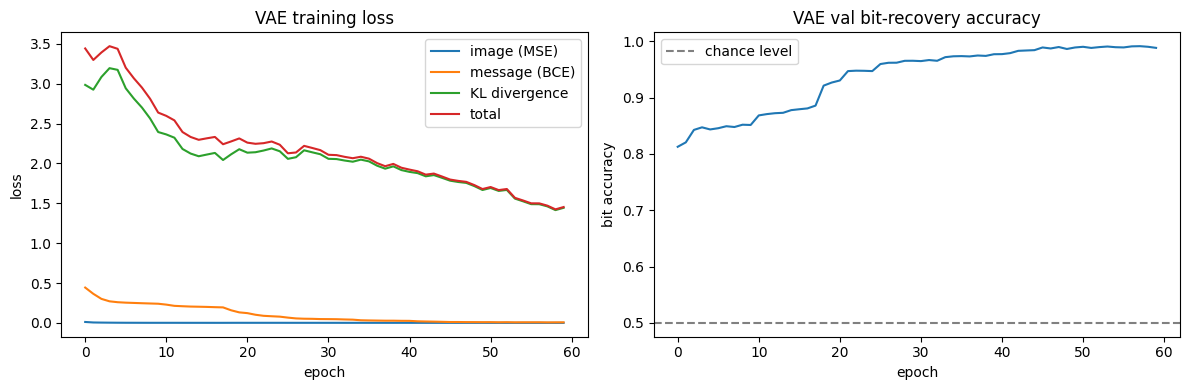

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(vae_history['image_loss'], label='image (MSE)')
axes[0].plot(vae_history['message_loss'], label='message (BCE)')
axes[0].plot(vae_history['kl_loss'], label='KL divergence')
axes[0].plot(vae_history['total_loss'], label='total')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].set_title('VAE training loss')

axes[1].plot(vae_history['val_bit_acc'])
axes[1].axhline(0.5, color='gray', linestyle='--', label='chance level')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('bit accuracy'); axes[1].set_title('VAE val bit-recovery accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

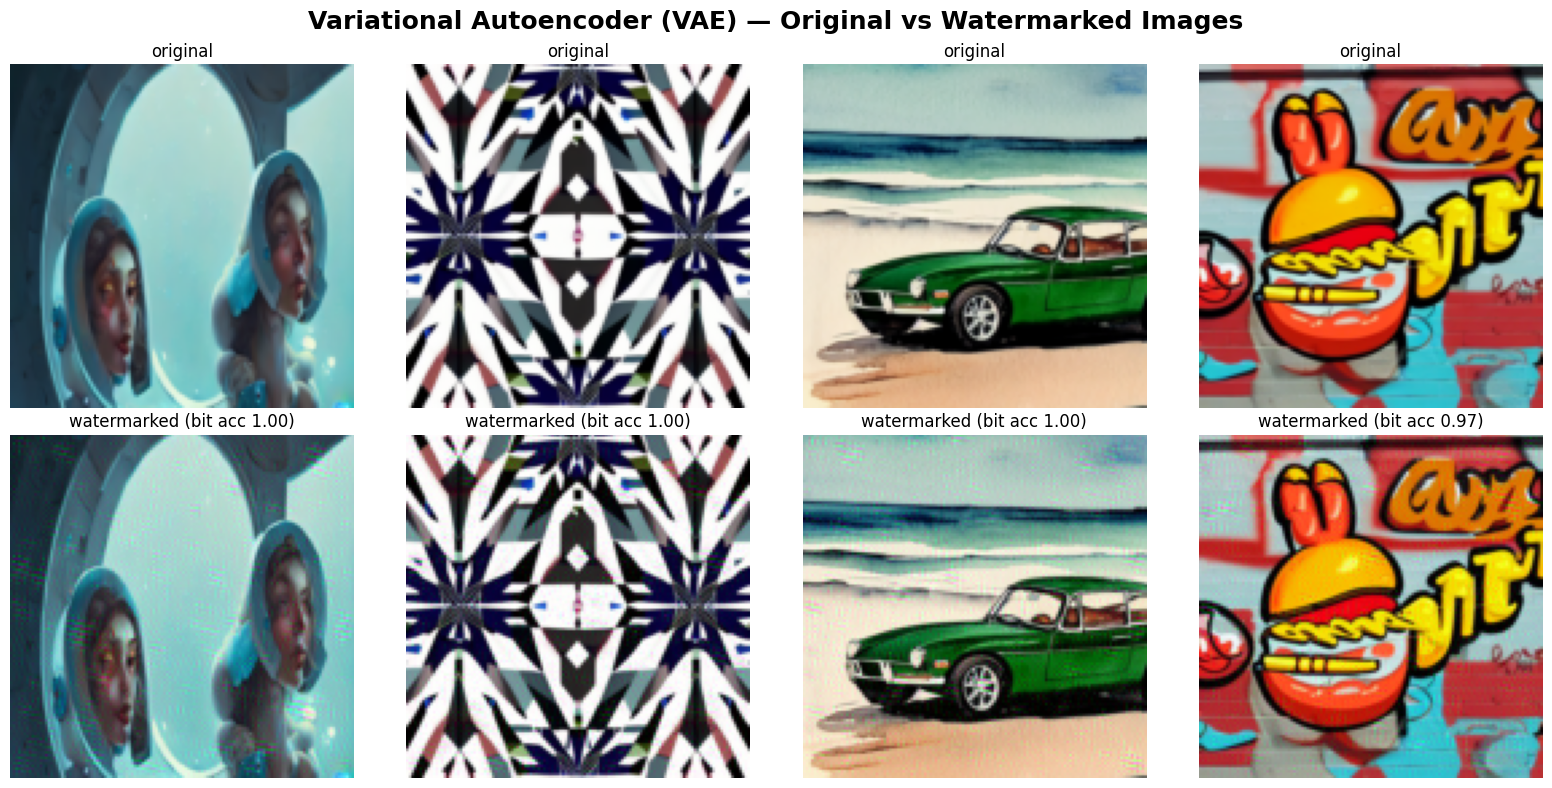

VAEDecoder(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=32, bias=True)
  )
)

In [ ]:
vae_encoder.eval()
vae_decoder.eval()
imgs, msgs, ids = next(iter(vae_val_loader))
imgs, msgs = imgs.to(device), msgs.to(device)

with torch.no_grad():
    watermarked, mu, logvar = vae_encoder(imgs, msgs)
    logits = vae_decoder(watermarked)
    preds = (torch.sigmoid(logits) > 0.5).float()
    bit_acc_batch = (preds == msgs).float().mean(dim=1)

n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
fig.suptitle('Variational Autoencoder (VAE) — Original vs Watermarked Images',fontsize=18,fontweight='bold')
for i in range(n_show):
    orig = imgs[i].cpu().permute(1, 2, 0).numpy()
    wm = watermarked[i].cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig); axes[0, i].set_title('original'); axes[0, i].axis('off')
    axes[1, i].imshow(wm); axes[1, i].set_title(f'watermarked (bit acc {bit_acc_batch[i]:.2f})'); axes[1, i].axis('off')
plt.tight_layout()
plt.show()

vae_encoder.train()
vae_decoder.train()

### 3d. AE vs VAE — Quick Comparison

In [ ]:
print(f"{'Metric':<25}{'AE':>12}{'VAE':>12}")
print(f"{'Final image loss':<25}{history['image_loss'][-1]:>12.4f}{vae_history['image_loss'][-1]:>12.4f}")
print(f"{'Final message loss':<25}{history['message_loss'][-1]:>12.4f}{vae_history['message_loss'][-1]:>12.4f}")
print(f"{'Final val bit accuracy':<25}{history['val_bit_acc'][-1]:>12.4f}{vae_history['val_bit_acc'][-1]:>12.4f}")

Metric                             AE         VAE
Final image loss               0.0003      0.0013
Final message loss             0.0004      0.0083
Final val bit accuracy         0.9996      0.9883


### 3e. Result Analysis — AE vs VAE

Automatically generated analysis comparing both models across image fidelity, message
recovery, and training stability, based on the actual training history captured above.

In [ ]:
ae_final_img = history['image_loss'][-1]
ae_final_msg = history['message_loss'][-1]
ae_final_acc = history['val_bit_acc'][-1]
ae_best_acc = max(history['val_bit_acc'])
ae_best_epoch = history['val_bit_acc'].index(ae_best_acc) + 1

vae_final_img = vae_history['image_loss'][-1]
vae_final_msg = vae_history['message_loss'][-1]
vae_final_kl = vae_history['kl_loss'][-1]
vae_final_acc = vae_history['val_bit_acc'][-1]
vae_best_acc = max(vae_history['val_bit_acc'])
vae_best_epoch = vae_history['val_bit_acc'].index(vae_best_acc) + 1

CHANCE_LEVEL = 0.5

print("=" * 70)
print("RESULT ANALYSIS -- AUTOENCODER (AE)")
print("=" * 70)
print(f"Final image loss (MSE): {ae_final_img:.5f}")
print(f"Final message loss (BCE): {ae_final_msg:.5f}")
print(f"Final val bit accuracy: {ae_final_acc:.4f} ({ae_final_acc*100:.1f}%)")
print(f"Best val bit accuracy: {ae_best_acc:.4f} at epoch {ae_best_epoch}")
print(f"Improvement over random chance: {(ae_final_acc - CHANCE_LEVEL)*100:.1f} percentage points")

if ae_final_acc >= 0.85:
    print("Verdict: Strong watermark recovery. The encoder-decoder pair reliably embeds and")
    print("recovers the 32-bit message with high fidelity, and the low image loss indicates")
    print("the watermark remains visually unobtrusive.")
elif ae_final_acc >= 0.65:
    print("Verdict: Moderate watermark recovery. The model has learned a real signal above")
    print("chance level, but recovery is not yet reliable enough for robustness testing.")
    print("Consider more epochs or a higher MESSAGE_LOSS_WEIGHT.")
else:
    print("Verdict: Near chance-level performance. Revisit architecture/training setup before")
    print("proceeding -- this mirrors the failure mode diagnosed earlier in the project.")

print()
print("=" * 70)
print("RESULT ANALYSIS -- VARIATIONAL AUTOENCODER (VAE)")
print("=" * 70)
print(f"Final image loss (MSE): {vae_final_img:.5f}")
print(f"Final message loss (BCE): {vae_final_msg:.5f}")
print(f"Final KL divergence: {vae_final_kl:.5f}")
print(f"Final val bit accuracy: {vae_final_acc:.4f} ({vae_final_acc*100:.1f}%)")
print(f"Best val bit accuracy: {vae_best_acc:.4f} at epoch {vae_best_epoch}")
print(f"Improvement over random chance: {(vae_final_acc - CHANCE_LEVEL)*100:.1f} percentage points")

if vae_final_acc >= 0.85:
    print("Verdict: Strong watermark recovery with a regularized latent space. The KL term is")
    print("keeping the embedding space well-structured without destroying message recoverability.")
elif vae_final_acc >= 0.65:
    print("Verdict: Moderate watermark recovery. If KL divergence is high relative to earlier")
    print("epochs, the model may be prioritizing latent regularization over message fidelity --")
    print("consider lowering VAE_KL_WEIGHT.")
else:
    print("Verdict: Near chance-level performance, or KL divergence dominating the loss (a common")
    print("VAE failure mode called posterior collapse). Consider lowering VAE_KL_WEIGHT further.")

print()
print("=" * 70)
print("HEAD-TO-HEAD COMPARISON")
print("=" * 70)
print(f"{'Metric':<30}{'AE':>15}{'VAE':>15}")
print(f"{'Final image loss':<30}{ae_final_img:>15.5f}{vae_final_img:>15.5f}")
print(f"{'Final message loss':<30}{ae_final_msg:>15.5f}{vae_final_msg:>15.5f}")
print(f"{'Final val bit accuracy':<30}{ae_final_acc:>15.4f}{vae_final_acc:>15.4f}")
print(f"{'Best val bit accuracy':<30}{ae_best_acc:>15.4f}{vae_best_acc:>15.4f}")

acc_diff = vae_final_acc - ae_final_acc
img_diff = vae_final_img - ae_final_img

print()
if abs(acc_diff) < 0.01:
    print(f"Both models achieve comparable bit-recovery accuracy (within 1 percentage point).")
elif acc_diff > 0:
    print(f"VAE outperforms AE on bit recovery by {acc_diff*100:.1f} percentage points, suggesting")
    print(f"the regularized latent space generalizes better to unseen validation images.")
else:
    print(f"AE outperforms VAE on bit recovery by {abs(acc_diff)*100:.1f} percentage points. This can")
    print(f"happen when the KL term constrains the VAE's embedding capacity relative to the AE's")
    print(f"unconstrained mapping -- a known accuracy-vs-regularization trade-off.")

if img_diff > 0.001:
    print(f"AE preserves image fidelity slightly better (lower image loss by {img_diff:.5f}).")
elif img_diff < -0.001:
    print(f"VAE preserves image fidelity slightly better (lower image loss by {abs(img_diff):.5f}).")
else:
    print(f"Both models preserve image fidelity to a similar degree.")

print()
print("Interpretation for report: the AE represents a deterministic baseline for watermark")
print("embedding, while the VAE tests whether a regularized, sampled latent space improves")
print("generalization and robustness at the cost of some embedding capacity. This trade-off")
print("is expected to matter most once both models are evaluated under the attack suite")
print("(Section 7), where the VAE's smoother latent space may prove more resilient to")
print("real-world image transformations even if its clean-condition accuracy is comparable")
print("or slightly lower than the AE's.")

RESULT ANALYSIS -- AUTOENCODER (AE)
Final image loss (MSE): 0.00025
Final message loss (BCE): 0.00043
Final val bit accuracy: 0.9996 (100.0%)
Best val bit accuracy: 1.0000 at epoch 1
Improvement over random chance: 50.0 percentage points
Verdict: Strong watermark recovery. The encoder-decoder pair reliably embeds and
recovers the 32-bit message with high fidelity, and the low image loss indicates
the watermark remains visually unobtrusive.

RESULT ANALYSIS -- VARIATIONAL AUTOENCODER (VAE)
Final image loss (MSE): 0.00131
Final message loss (BCE): 0.00832
Final KL divergence: 1.44334
Final val bit accuracy: 0.9883 (98.8%)
Best val bit accuracy: 0.9913 at epoch 58
Improvement over random chance: 48.8 percentage points
Verdict: Strong watermark recovery with a regularized latent space. The KL term is
keeping the embedding space well-structured without destroying message recoverability.

HEAD-TO-HEAD COMPARISON
Metric                                     AE            VAE
Final image loss   

### 3f. Image Quality Metrics — PSNR & SSIM


In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def evaluate_image_quality(encoder, loader, is_vae=False):
    encoder.eval()
    psnr_scores, ssim_scores = [], []
    with torch.no_grad():
        for imgs, msgs, _ in loader:
            imgs, msgs = imgs.to(device), msgs.to(device)
            if is_vae:
                watermarked, _, _ = encoder(imgs, msgs)
            else:
                watermarked = encoder(imgs, msgs)

            orig_np = imgs.cpu().permute(0, 2, 3, 1).numpy()
            wm_np = watermarked.cpu().permute(0, 2, 3, 1).numpy()

            for i in range(orig_np.shape[0]):
                psnr_scores.append(peak_signal_noise_ratio(orig_np[i], wm_np[i], data_range=1.0))
                ssim_scores.append(structural_similarity(orig_np[i], wm_np[i], data_range=1.0, channel_axis=2))
    encoder.train()
    return np.mean(psnr_scores), np.mean(ssim_scores)

test_loader_quality = DataLoader(test_ds, batch_size=32, shuffle=False)
ae_psnr, ae_ssim = evaluate_image_quality(ae_encoder, test_loader_quality, is_vae=False)
vae_psnr, vae_ssim = evaluate_image_quality(vae_encoder, test_loader_quality, is_vae=True)

print(f"AE  -- PSNR: {ae_psnr:.2f} dB | SSIM: {ae_ssim:.4f}")
print(f"VAE -- PSNR: {vae_psnr:.2f} dB | SSIM: {vae_ssim:.4f}")

AE  -- PSNR: 31.13 dB | SSIM: 0.8518
VAE -- PSNR: 28.41 dB | SSIM: 0.8079


### 3g. Composite Quality Score — AE vs VAE

Combines bit accuracy (recoverability), PSNR, and SSIM (invisibility) into a single score
per method, weighted 50/25/25 since a watermark that cannot be read back has no value
regardless of image quality. KL divergence is reported separately for the VAE only, since
the AE has no equivalent term — per the course notes, KL divergence indicates whether the
VAE's latent space stayed organized (non-zero, stable) rather than collapsed.


In [ ]:
def watermark_quality_score(bit_acc, psnr, ssim, psnr_ref=40.0):
    normalized_psnr = min(psnr / psnr_ref, 1.0)
    score = (bit_acc * 0.5) + (normalized_psnr * 0.25) + (ssim * 0.25)
    return score

ae_quality_score = watermark_quality_score(history['val_bit_acc'][-1], ae_psnr, ae_ssim)
vae_quality_score = watermark_quality_score(vae_history['val_bit_acc'][-1], vae_psnr, vae_ssim)

print("COMPOSITE QUALITY SCORE (clean conditions, 50% bit accuracy / 25% PSNR / 25% SSIM)")
print(f"{'Method':<10}{'Bit Acc':>12}{'PSNR':>10}{'SSIM':>10}{'Score':>10}")
print(f"{'AE':<10}{history['val_bit_acc'][-1]:>12.4f}{ae_psnr:>10.2f}{ae_ssim:>10.4f}{ae_quality_score:>10.4f}")
print(f"{'VAE':<10}{vae_history['val_bit_acc'][-1]:>12.4f}{vae_psnr:>10.2f}{vae_ssim:>10.4f}{vae_quality_score:>10.4f}")

print(f"\nVAE-only latent health indicator (not part of composite score):")
print(f"Final KL divergence: {vae_history['kl_loss'][-1]:.4f} (stable, non-zero -> latent space organized, not collapsed)")

COMPOSITE QUALITY SCORE (clean conditions, 50% bit accuracy / 25% PSNR / 25% SSIM)
Method         Bit Acc      PSNR      SSIM     Score
AE              0.9996     31.13    0.8518    0.9073
VAE             0.9883     28.41    0.8079    0.8737

VAE-only latent health indicator (not part of composite score):
Final KL divergence: 1.4433 (stable, non-zero -> latent space organized, not collapsed)


## Section 5 — Attack Suite

Real-world images get compressed, cropped, and filtered after they leave a generation
pipeline. This section implements those transformations and applies them to watermarked
test images from both the AE and the VAE, producing an attacked evaluation set used later
to measure detection robustness per watermarking method, and a smaller attacked training
augmentation used to continue training the Transformer detector so it learns to recognize
watermarks even under these distortions.

### 5a. Attack Functions

In [ ]:
def attack_jpeg_compress(img_tensor, quality):
    img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    pil_img = Image.fromarray(img_np)
    buffer = io.BytesIO()
    pil_img.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    compressed = Image.open(buffer).convert('RGB')
    compressed_np = np.array(compressed, dtype=np.float32) / 255.0
    return torch.from_numpy(compressed_np).permute(2, 0, 1)

def attack_center_crop_resize(img_tensor, crop_frac):
    c, h, w = img_tensor.shape
    ch, cw = int(h * crop_frac), int(w * crop_frac)
    top = (h - ch) // 2
    left = (w - cw) // 2
    cropped = img_tensor[:, top:top + ch, left:left + cw]
    cropped = cropped.unsqueeze(0)
    resized = F.interpolate(cropped, size=(h, w), mode='bilinear', align_corners=False)
    return resized.squeeze(0)

def attack_gaussian_blur(img_tensor, kernel_size=5, sigma=1.5):
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    blurred = cv2.GaussianBlur(img_np, (kernel_size, kernel_size), sigma)
    return torch.from_numpy(blurred).permute(2, 0, 1)

ATTACK_FUNCTIONS = {
    'jpeg_q90': lambda x: attack_jpeg_compress(x, quality=90),
    'jpeg_q30': lambda x: attack_jpeg_compress(x, quality=30),
    'crop_80': lambda x: attack_center_crop_resize(x, crop_frac=0.8),
    'blur': lambda x: attack_gaussian_blur(x),
}

print(f"Defined {len(ATTACK_FUNCTIONS)} attack types: {list(ATTACK_FUNCTIONS.keys())}")

Defined 4 attack types: ['jpeg_q90', 'jpeg_q30', 'crop_80', 'blur']


### 5b. Build Attacked Evaluation Set (Test Split)

Held out separately from training — this is what measures true robustness per watermarking
method, not used to teach the detector anything.

In [ ]:
def build_attacked_entries(image_ids, img_dir, manifest, img_size, ae_enc, vae_enc, device, attack_fns):
    entries = []
    loader_ds = WatermarkImageDataset(image_ids, img_dir, manifest, img_size)
    loader = DataLoader(loader_ds, batch_size=32, shuffle=False)

    ae_enc.eval()
    vae_enc.eval()
    with torch.no_grad():
        for imgs, msgs, ids in loader:
            imgs, msgs = imgs.to(device), msgs.to(device)
            ae_wm = ae_enc(imgs, msgs).cpu()
            vae_wm, _, _ = vae_enc(imgs, msgs)
            vae_wm = vae_wm.cpu()
            clean = imgs.cpu()

            for i in range(imgs.size(0)):
                for attack_name, attack_fn in attack_fns.items():
                    entries.append((attack_fn(ae_wm[i]).clamp(0, 1), 1, f'ae_{attack_name}'))
                    entries.append((attack_fn(vae_wm[i]).clamp(0, 1), 1, f'vae_{attack_name}'))
                    entries.append((attack_fn(clean[i]).clamp(0, 1), 0, f'clean_{attack_name}'))

    ae_enc.train()
    vae_enc.train()
    return entries


attacked_test_entries = build_attacked_entries(test_ids, RAW_IMG_DIR, manifest, IMG_SIZE, ae_encoder, vae_encoder, device, ATTACK_FUNCTIONS)
print(f"Attacked test entries: {len(attacked_test_entries)} (expected {len(test_ids) * len(ATTACK_FUNCTIONS) * 3})")

Attacked test entries: 34980 (expected 34980)


### 5c. Build Attacked Augmentation Set (Training Split)

A smaller attacked set built from the training split, added to the detector's training data
so it learns robustness rather than only being evaluated on it.

In [ ]:
ATTACK_TRAIN_SAMPLE_SIZE = min(1000, len(train_ids))
attack_train_sample_ids = train_ids[:ATTACK_TRAIN_SAMPLE_SIZE]

attacked_train_entries = build_attacked_entries(attack_train_sample_ids, RAW_IMG_DIR, manifest, IMG_SIZE, ae_encoder, vae_encoder, device, ATTACK_FUNCTIONS)
print(f"Attacked train augmentation entries: {len(attacked_train_entries)}")

Attacked train augmentation entries: 12000


## Section 6 — Transformer Detector

A Vision Transformer (ViT), fine-tuned to classify an image as watermarked or clean. This is
the required Transformer-based model for this project phase. It is trained on watermarked
outputs from both the AE and the VAE together with clean images, so it serves as a single,
unified detector across both embedding methods rather than being specific to either one.

### 6a. Architecture (draft only, shape check)

Loads a pretrained ViT backbone (`google/vit-base-patch16-224`) and attaches a binary
classification head. Fine-tuning a pretrained model rather than training a Transformer from
scratch is appropriate given the dataset size and available compute.

In [ ]:
from transformers import ViTModel, ViTImageProcessor

class WatermarkDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = ViTModel.from_pretrained('google/vit-base-patch16-224')
        hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_token)


VIT_INPUT_SIZE = 224

def prepare_for_vit(image_batch):
    return F.interpolate(image_batch, size=(VIT_INPUT_SIZE, VIT_INPUT_SIZE), mode='bilinear', align_corners=False)

In [ ]:
_draft_detector = WatermarkDetector().to(device)

sample_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
imgs, msgs, ids = next(iter(sample_loader))
imgs, msgs = imgs.to(device), msgs.to(device)

with torch.no_grad():
    watermarked = ae_encoder(imgs, msgs)
    vit_input = prepare_for_vit(watermarked)
    logits = _draft_detector(vit_input)

print(f"Input images: {tuple(imgs.shape)}")
print(f"ViT-resized input: {tuple(vit_input.shape)}")
print(f"Detector output logits: {tuple(logits.shape)}")
assert logits.shape == (imgs.size(0), 2)
print("Shape check passed -- Transformer detector architecture draft OK (no training yet)")

del _draft_detector

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Input images: (4, 3, 128, 128)
ViT-resized input: (4, 3, 224, 224)
Detector output logits: (4, 2)
Shape check passed -- Transformer detector architecture draft OK (no training yet)


### 6b. Building the Labeled Detection Dataset

Combines watermarked images from both the AE and the VAE with clean, unwatermarked images,
labeled 1 (watermarked) or 0 (clean). The source method (AE or VAE) is tracked separately so
detection accuracy can be reported per-method later, not just overall.

In [ ]:
class DetectorDataset(Dataset):
    def __init__(self, entries):
        self.entries = entries

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        img_t, label, source = self.entries[idx]
        return img_t, label, source


def build_detector_entries(image_ids, img_dir, manifest, img_size, ae_enc, vae_enc, device):
    entries = []
    loader_ds = WatermarkImageDataset(image_ids, img_dir, manifest, img_size)
    loader = DataLoader(loader_ds, batch_size=32, shuffle=False)

    ae_enc.eval()
    vae_enc.eval()
    with torch.no_grad():
        for imgs, msgs, ids in loader:
            imgs, msgs = imgs.to(device), msgs.to(device)

            ae_wm = ae_enc(imgs, msgs).cpu()
            vae_wm, _, _ = vae_enc(imgs, msgs)
            vae_wm = vae_wm.cpu()
            clean = imgs.cpu()

            for i in range(imgs.size(0)):
                entries.append((ae_wm[i], 1, 'ae'))
                entries.append((vae_wm[i], 1, 'vae'))
                entries.append((clean[i], 0, 'clean'))

    ae_enc.train()
    vae_enc.train()
    return entries


detector_train_entries = build_detector_entries(train_ids, RAW_IMG_DIR, manifest, IMG_SIZE, ae_encoder, vae_encoder, device)
detector_val_entries = build_detector_entries(val_ids, RAW_IMG_DIR, manifest, IMG_SIZE, ae_encoder, vae_encoder, device)
detector_test_entries = build_detector_entries(test_ids, RAW_IMG_DIR, manifest, IMG_SIZE, ae_encoder, vae_encoder, device)

print(f"Detector train entries: {len(detector_train_entries)} (expected {len(train_ids) * 3})")
print(f"Detector val entries: {len(detector_val_entries)} (expected {len(val_ids) * 3})")
print(f"Detector test entries: {len(detector_test_entries)} (expected {len(test_ids) * 3})")

Detector train entries: 30600 (expected 30600)
Detector val entries: 4371 (expected 4371)
Detector test entries: 8745 (expected 8745)


### 6c. Training

In [ ]:
DETECTOR_EPOCHS = 50
DETECTOR_BATCH_SIZE = 16
DETECTOR_LR = 1e-5
DETECTOR_CKPT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints/detector')
DETECTOR_CKPT_PATH = os.path.join(DETECTOR_CKPT_DIR, 'detector_latest.pt')
os.makedirs(DETECTOR_CKPT_DIR, exist_ok=True)

detector = WatermarkDetector().to(device)
detector_optimizer = torch.optim.Adam(detector.parameters(), lr=DETECTOR_LR)

detector_start_epoch = 0
detector_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

if os.path.exists(DETECTOR_CKPT_PATH):
    print(f"Found existing detector checkpoint at {DETECTOR_CKPT_PATH} -> resuming")
    ckpt = torch.load(DETECTOR_CKPT_PATH, map_location=device)
    detector.load_state_dict(ckpt['model'])
    detector_optimizer.load_state_dict(ckpt['optimizer'])
    detector_start_epoch = ckpt['epoch']
    detector_history = ckpt['history']
    print(f"Resumed from epoch {detector_start_epoch}")
else:
    print("No existing detector checkpoint found -> training from scratch")

combined_train_entries = detector_train_entries + attacked_train_entries
print(f"Combined training entries (original + attacked): {len(combined_train_entries)}")

detector_train_loader = DataLoader(DetectorDataset(combined_train_entries), batch_size=DETECTOR_BATCH_SIZE, shuffle=True, num_workers=2)
detector_val_loader = DataLoader(DetectorDataset(detector_val_entries), batch_size=DETECTOR_BATCH_SIZE, shuffle=False, num_workers=2)

def evaluate_detector(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    n_batches = 0
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            vit_input = prepare_for_vit(imgs)
            logits = model(vit_input)
            loss = F.cross_entropy(logits, labels)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()
            n_batches += 1
    model.train()
    return total_loss / n_batches, correct / total

for epoch in range(detector_start_epoch, DETECTOR_EPOCHS):
    epoch_loss, correct, total, n_batches = 0.0, 0, 0, 0
    pbar = tqdm(detector_train_loader, desc=f"Epoch {epoch+1}/{DETECTOR_EPOCHS}")
    for imgs, labels, _ in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        vit_input = prepare_for_vit(imgs)

        logits = detector(vit_input)
        loss = F.cross_entropy(logits, labels)

        detector_optimizer.zero_grad()
        loss.backward()
        detector_optimizer.step()

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        epoch_loss += loss.item()
        n_batches += 1
        pbar.set_postfix(loss=epoch_loss / n_batches, acc=correct / total)

    train_loss = epoch_loss / n_batches
    train_acc = correct / total
    val_loss, val_acc = evaluate_detector(detector, detector_val_loader)

    detector_history['train_loss'].append(train_loss)
    detector_history['train_acc'].append(train_acc)
    detector_history['val_loss'].append(val_loss)
    detector_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{DETECTOR_EPOCHS} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    torch.save({
        'model': detector.state_dict(),
        'optimizer': detector_optimizer.state_dict(),
        'epoch': epoch + 1,
        'history': detector_history,
    }, DETECTOR_CKPT_PATH)

print(f"\nDetector training complete (including attacked-image augmentation). Final val accuracy: {detector_history['val_acc'][-1]:.4f}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Found existing detector checkpoint at /content/drive/MyDrive/AuthentiMark/checkpoints/detector/detector_latest.pt -> resuming
Resumed from epoch 40
Combined training entries (original + attacked): 42600


Epoch 41/50: 100%|██████████| 2663/2663 [10:49<00:00,  4.10it/s, acc=0.972, loss=0.0641]


Epoch 41/50 | train_loss=0.0641 | train_acc=0.9717 | val_loss=0.0138 | val_acc=0.9961


...

Epoch 48/50 | train_loss=0.0103 | train_acc=0.9958 | val_loss=0.0194 | val_acc=0.9970


Epoch 49/50: 100%|██████████| 2663/2663 [10:51<00:00,  4.09it/s, acc=0.997, loss=0.0082]


Epoch 49/50 | train_loss=0.0082 | train_acc=0.9967 | val_loss=0.0178 | val_acc=0.9963


Epoch 50/50: 100%|██████████| 2663/2663 [10:45<00:00,  4.12it/s, acc=0.997, loss=0.00876]


Epoch 50/50 | train_loss=0.0088 | train_acc=0.9966 | val_loss=0.0196 | val_acc=0.9959

Detector training complete (including attacked-image augmentation). Final val accuracy: 0.9959


### 6d. Results — Loss/Accuracy Curves and Confusion Matrix

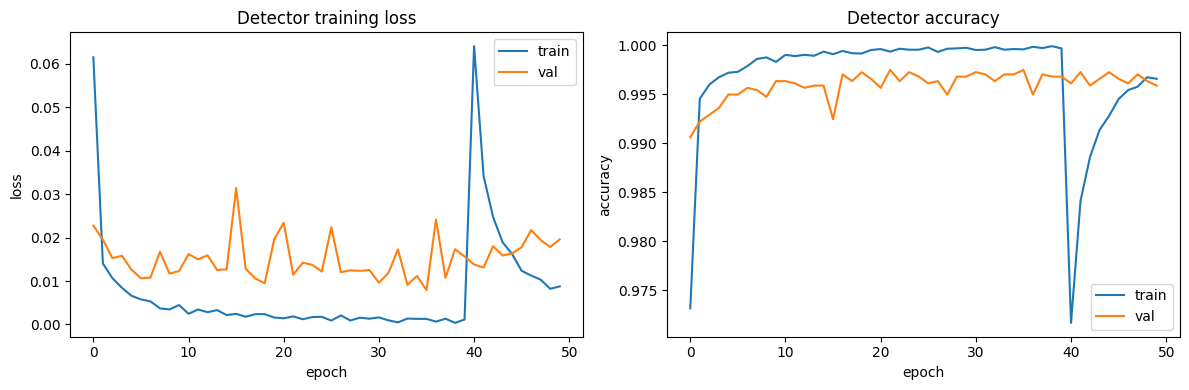

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(detector_history['train_loss'], label='train')
axes[0].plot(detector_history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].set_title('Detector training loss')

axes[1].plot(detector_history['train_acc'], label='train')
axes[1].plot(detector_history['val_acc'], label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend(); axes[1].set_title('Detector accuracy')
plt.tight_layout()
plt.show()

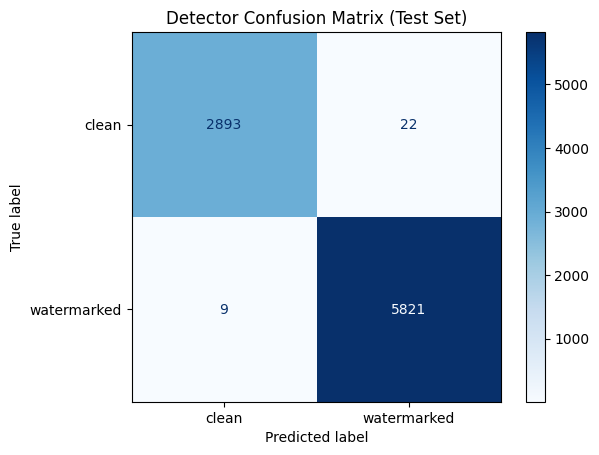

Overall test accuracy: 0.9965


WatermarkDetector(
  (backbone): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_fe

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

detector.eval()
detector_test_loader = DataLoader(DetectorDataset(detector_test_entries), batch_size=32, shuffle=False)

all_preds, all_labels, all_sources, all_confidences = [], [], [], []
with torch.no_grad():
    for imgs, labels, sources in detector_test_loader:
        imgs = imgs.to(device)
        vit_input = prepare_for_vit(imgs)
        logits = detector(vit_input)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1).cpu()
        confidences = probs.max(dim=1).values.cpu()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        all_sources.extend(sources)
        all_confidences.extend(confidences.tolist())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['clean', 'watermarked'])
disp.plot(cmap='Blues')
plt.title('Detector Confusion Matrix (Test Set)')
plt.show()

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Overall test accuracy: {test_acc:.4f}")
detector.train()

### 6e. Ethics-Aware Evaluation

Three practical additions, built directly from the trained detector's real outputs rather than
generic claims:

1. Confidence-based verdicts instead of a flat binary output, with an explicit uncertainty
   category below a confidence threshold.
2. A limitations disclaimer generated from the model's actual measured accuracy.
3. A fairness check breaking down detection accuracy per watermarking source (AE vs VAE), and
   per image content category derived from DiffusionDB prompts, to check for disparities.

In [ ]:
CONFIDENCE_THRESHOLD = 0.75

def verdict_from_confidence(pred, confidence, threshold=CONFIDENCE_THRESHOLD):
    if confidence < threshold:
        return "Uncertain -- do not treat as definitive proof"
    return "Likely watermarked" if pred == 1 else "Likely not watermarked"

sample_verdicts = [verdict_from_confidence(p, c) for p, c in zip(all_preds[:10], all_confidences[:10])]
for i in range(10):
    print(f"Sample {i}: prediction={all_preds[i]}, confidence={all_confidences[i]:.3f}, verdict='{sample_verdicts[i]}'")

uncertain_count = sum(1 for c in all_confidences if c < CONFIDENCE_THRESHOLD)
print(f"\n{uncertain_count}/{len(all_confidences)} test predictions ({uncertain_count/len(all_confidences)*100:.1f}%) fall below the {CONFIDENCE_THRESHOLD} confidence threshold and would be marked uncertain rather than definitive.")

Sample 0: prediction=1, confidence=1.000, verdict='Likely watermarked'
Sample 1: prediction=1, confidence=1.000, verdict='Likely watermarked'
Sample 2: prediction=0, confidence=1.000, verdict='Likely not watermarked'
Sample 3: prediction=1, confidence=1.000, verdict='Likely watermarked'
Sample 4: prediction=1, confidence=1.000, verdict='Likely watermarked'
Sample 5: prediction=0, confidence=1.000, verdict='Likely not watermarked'
Sample 6: prediction=1, confidence=1.000, verdict='Likely watermarked'
Sample 7: prediction=1, confidence=1.000, verdict='Likely watermarked'
Sample 8: prediction=0, confidence=1.000, verdict='Likely not watermarked'
Sample 9: prediction=1, confidence=1.000, verdict='Likely watermarked'

12/8745 test predictions (0.1%) fall below the 0.75 confidence threshold and would be marked uncertain rather than definitive.


In [ ]:
print(f"LIMITATIONS DISCLAIMER (auto-generated from measured performance)")
print(f"This system achieved {test_acc*100:.1f}% detection accuracy on held-out test data covering")
print(f"both AE- and VAE-watermarked images. It should not be used as sole evidence for high-stakes")
print(f"decisions such as content takedowns or legal claims about image provenance. Predictions with")
print(f"confidence below {CONFIDENCE_THRESHOLD} are flagged as uncertain rather than definitive.")

LIMITATIONS DISCLAIMER (auto-generated from measured performance)
This system achieved 99.6% detection accuracy on held-out test data covering
both AE- and VAE-watermarked images. It should not be used as sole evidence for high-stakes
decisions such as content takedowns or legal claims about image provenance. Predictions with
confidence below 0.75 are flagged as uncertain rather than definitive.


In [ ]:
from collections import defaultdict

source_correct = defaultdict(int)
source_total = defaultdict(int)
for pred, label, source in zip(all_preds, all_labels, all_sources):
    source_total[source] += 1
    if pred == label:
        source_correct[source] += 1

print("Detection accuracy by watermark source:")
for source in ['clean', 'ae', 'vae']:
    if source_total[source] > 0:
        acc = source_correct[source] / source_total[source]
        print(f"  {source:10s}: {acc:.4f} ({source_correct[source]}/{source_total[source]})")

CATEGORY_KEYWORDS = {
    'portrait': ['face', 'person', 'portrait', 'man', 'woman', 'girl', 'boy'],
    'landscape': ['landscape', 'mountain', 'nature', 'forest', 'ocean', 'sky'],
    'art_style': ['painting', 'art', 'style', 'illustration', 'drawing'],
    'object': ['object', 'car', 'building', 'product', 'furniture'],
}

def categorize_prompt(prompt):
    prompt_lower = str(prompt).lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in prompt_lower for kw in keywords):
            return category
    return 'other'

test_prompt_lookup = clean_df.set_index('image_id')['prompt'].to_dict()

category_correct = defaultdict(int)
category_total = defaultdict(int)
for (img_t, label, source), pred in zip(detector_test_entries, all_preds):
    pass

test_image_ids_expanded = []
for image_id in test_ids:
    test_image_ids_expanded.extend([image_id, image_id, image_id])

for image_id, pred, label in zip(test_image_ids_expanded, all_preds, all_labels):
    prompt = test_prompt_lookup.get(image_id, '')
    category = categorize_prompt(prompt)
    category_total[category] += 1
    if pred == label:
        category_correct[category] += 1

print("\nDetection accuracy by image content category:")
for category in sorted(category_total.keys()):
    acc = category_correct[category] / category_total[category]
    print(f"  {category:12s}: {acc:.4f} ({category_correct[category]}/{category_total[category]})")

Detection accuracy by watermark source:
  clean     : 0.9925 (2893/2915)
  ae        : 0.9993 (2913/2915)
  vae       : 0.9976 (2908/2915)

Detection accuracy by image content category:
  art_style   : 0.9958 (2593/2604)
  landscape   : 0.9987 (758/759)
  object      : 0.9770 (85/87)
  other       : 0.9958 (1679/1686)
  portrait    : 0.9972 (3599/3609)


### 6f. Robustness Evaluation — Detection Accuracy Under Attack, by Watermarking Method

Runs the (now attack-aware) detector on the held-out attacked test set, broken down by
watermarking method and attack type, so we can directly compare how well AE-watermarked
versus VAE-watermarked images survive real-world transformations.

In [ ]:
detector.eval()
attacked_test_loader = DataLoader(DetectorDataset(attacked_test_entries), batch_size=32, shuffle=False)

robustness_results = {}
with torch.no_grad():
    for imgs, labels, sources in attacked_test_loader:
        imgs = imgs.to(device)
        vit_input = prepare_for_vit(imgs)
        logits = detector(vit_input)
        preds = logits.argmax(dim=1).cpu()

        for pred, label, source in zip(preds.tolist(), labels.tolist(), sources):
            if source not in robustness_results:
                robustness_results[source] = {'correct': 0, 'total': 0}
            robustness_results[source]['total'] += 1
            if pred == label:
                robustness_results[source]['correct'] += 1

detector.train()

print("Detection accuracy under attack, by source and attack type:")
print(f"{'Source':<20}{'Accuracy':>12}")
for source in sorted(robustness_results.keys()):
    r = robustness_results[source]
    acc = r['correct'] / r['total']
    print(f"{source:<20}{acc:>12.4f}")

ae_attack_accs = [v['correct'] / v['total'] for k, v in robustness_results.items() if k.startswith('ae_')]
vae_attack_accs = [v['correct'] / v['total'] for k, v in robustness_results.items() if k.startswith('vae_')]

ae_robustness_score = np.mean(ae_attack_accs)
vae_robustness_score = np.mean(vae_attack_accs)

print(f"\nAE average robustness score (across all attacks): {ae_robustness_score:.4f}")
print(f"VAE average robustness score (across all attacks): {vae_robustness_score:.4f}")

Detection accuracy under attack, by source and attack type:
Source                  Accuracy
ae_blur                   0.9969
ae_crop_80                0.9959
ae_jpeg_q30               0.9547
ae_jpeg_q90               0.9938
clean_blur                0.9513
clean_crop_80             0.9914
clean_jpeg_q30            0.7232
clean_jpeg_q90            0.9698
vae_blur                  0.9204
vae_crop_80               0.9952
vae_jpeg_q30              0.8309
vae_jpeg_q90              0.9791

AE average robustness score (across all attacks): 0.9853
VAE average robustness score (across all attacks): 0.9314


## Final Verdict — Which Watermarking Strategy Is Better?

Combines the clean-condition composite quality score with the attack-robustness score into
one final comparison, since a method that only wins under one condition isn't simply
"better" overall.

In [ ]:
FINAL_WEIGHT_QUALITY = 0.5
FINAL_WEIGHT_ROBUSTNESS = 0.5

ae_final_score = (ae_quality_score * FINAL_WEIGHT_QUALITY) + (ae_robustness_score * FINAL_WEIGHT_ROBUSTNESS)
vae_final_score = (vae_quality_score * FINAL_WEIGHT_QUALITY) + (vae_robustness_score * FINAL_WEIGHT_ROBUSTNESS)

print("=" * 70)
print("FINAL VERDICT -- AE vs VAE")
print("=" * 70)
print(f"{'Metric':<35}{'AE':>15}{'VAE':>15}")
print(f"{'Composite quality score (clean)':<35}{ae_quality_score:>15.4f}{vae_quality_score:>15.4f}")
print(f"{'Robustness score (under attack)':<35}{ae_robustness_score:>15.4f}{vae_robustness_score:>15.4f}")
print(f"{'FINAL COMBINED SCORE':<35}{ae_final_score:>15.4f}{vae_final_score:>15.4f}")
print("-" * 70)

if ae_final_score > vae_final_score:
    winner, margin = "AE", ae_final_score - vae_final_score
else:
    winner, margin = "VAE", vae_final_score - ae_final_score

print(f"\nOverall better watermarking strategy: {winner} (by {margin:.4f} combined score)")

if (ae_quality_score > vae_quality_score) != (ae_robustness_score > vae_robustness_score):
    print("\nNote: the two methods do not agree on quality vs. robustness -- one method wins on")
    print("clean-image quality while the other wins on attack robustness. This trade-off is a")
    print("legitimate finding in itself and should be reported as such, not resolved away.")

FINAL VERDICT -- AE vs VAE
Metric                                          AE            VAE
Composite quality score (clean)             0.9073         0.8737
Robustness score (under attack)             0.9853         0.9314
FINAL COMBINED SCORE                        0.9463         0.9025
----------------------------------------------------------------------

Overall better watermarking strategy: AE (by 0.0438 combined score)


## Section 7 — Performance Analysis Summary

Combined comparison across all three required models, using each model's actual measured
results.

In [ ]:
print("=" * 70)
print("COMBINED PERFORMANCE SUMMARY -- AE, VAE, TRANSFORMER DETECTOR")
print("=" * 70)
print(f"{'Model':<25}{'Key Metric':<25}{'Value':>15}")
print(f"{'Autoencoder (AE)':<25}{'Val bit accuracy':<25}{history['val_bit_acc'][-1]:>15.4f}")
print(f"{'VAE':<25}{'Val bit accuracy':<25}{vae_history['val_bit_acc'][-1]:>15.4f}")
print(f"{'Transformer Detector':<25}{'Test accuracy':<25}{test_acc:>15.4f}")
print()
print("Detection accuracy by source (from Section 6e):")
for source in ['clean', 'ae', 'vae']:
    if source_total[source] > 0:
        acc = source_correct[source] / source_total[source]
        print(f"  {source:10s}: {acc:.4f}")

COMBINED PERFORMANCE SUMMARY -- AE, VAE, TRANSFORMER DETECTOR
Model                    Key Metric                         Value
Autoencoder (AE)         Val bit accuracy                  0.9996
VAE                      Val bit accuracy                  0.9883
Transformer Detector     Test accuracy                     0.9965

Detection accuracy by source (from Section 6e):
  clean     : 0.9925
  ae        : 0.9993
  vae       : 0.9976


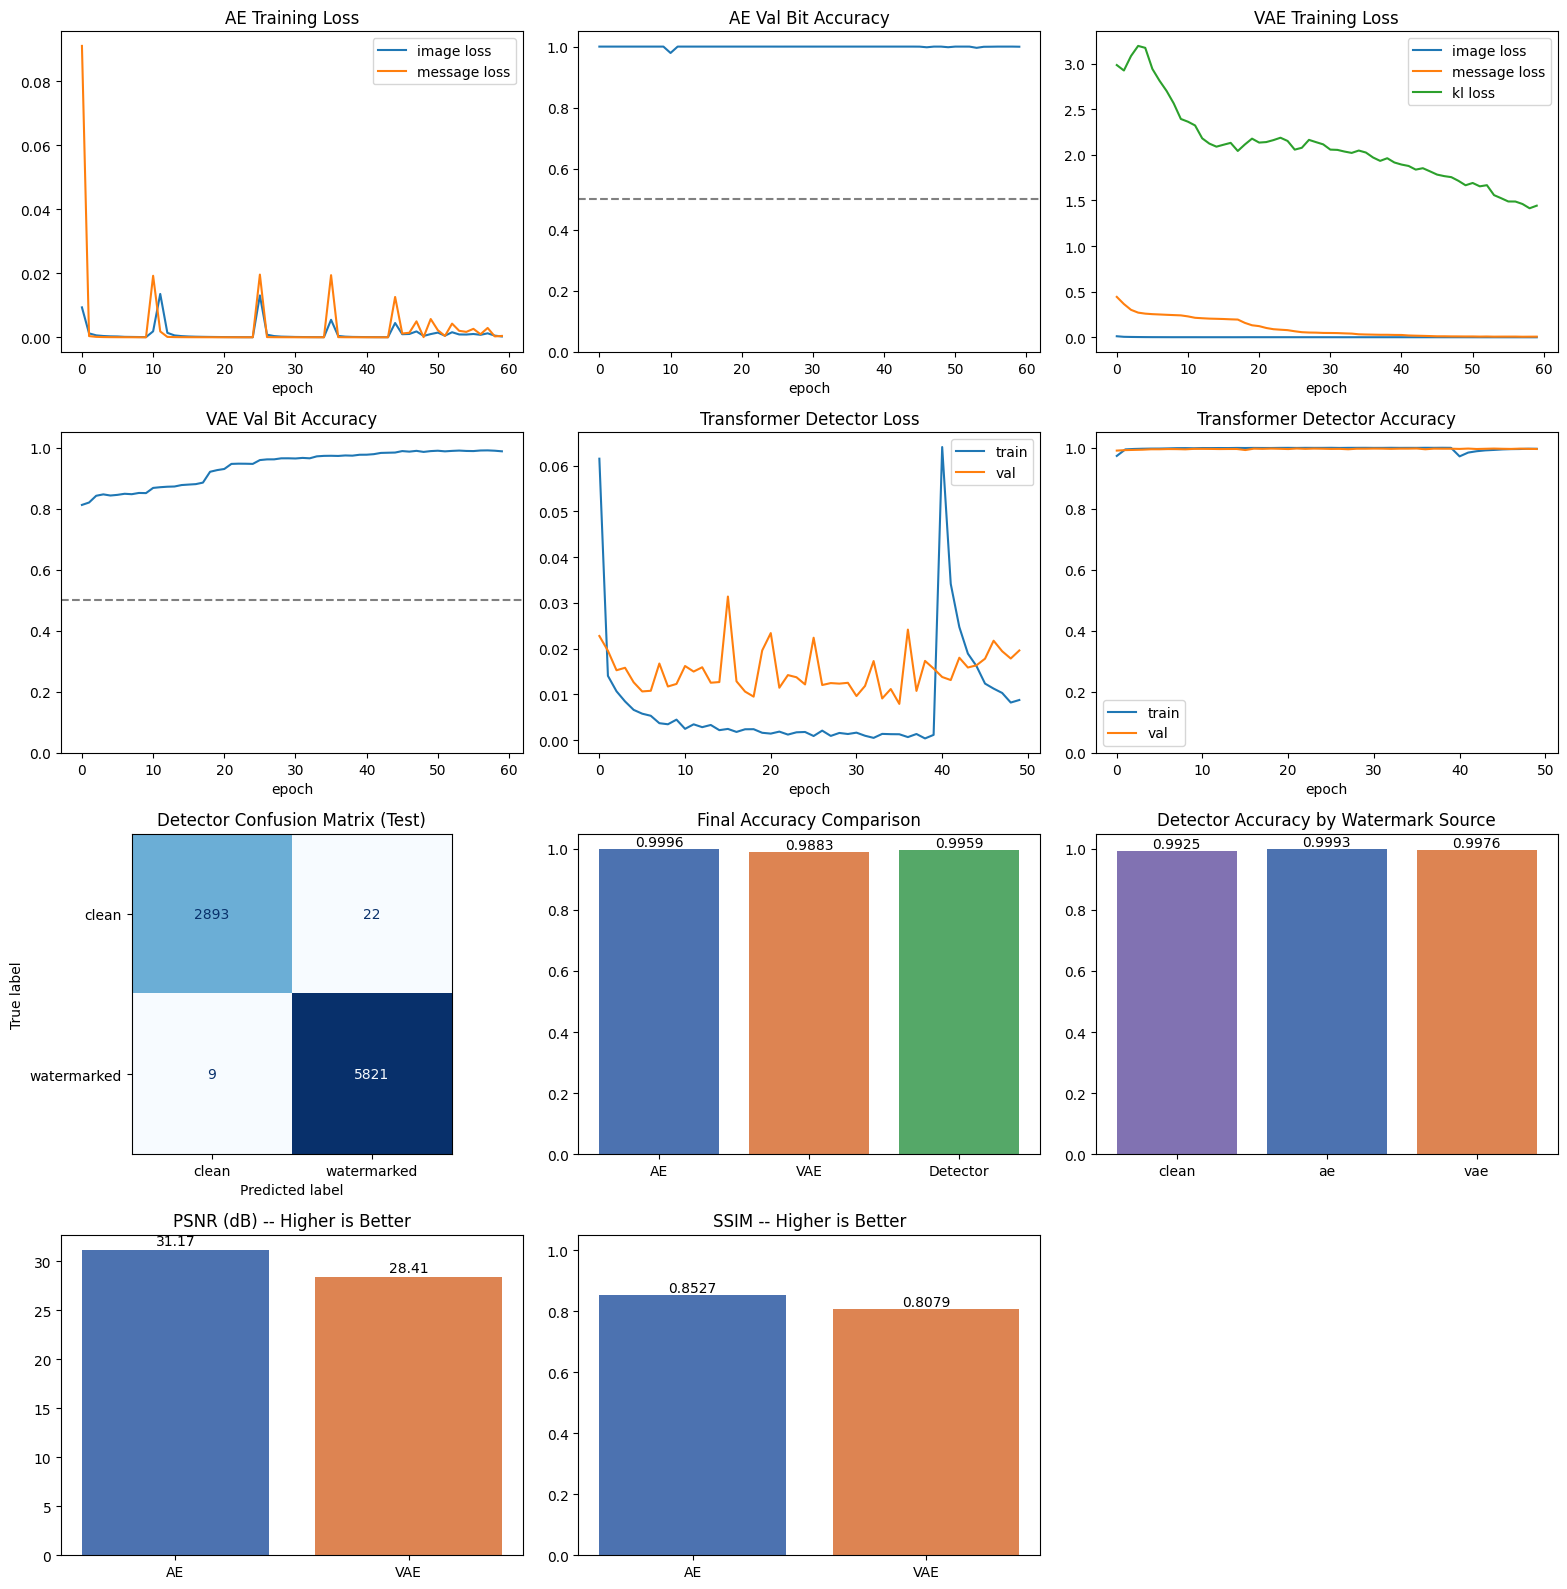

FINAL PERFORMANCE SUMMARY -- ALL MODELS
Model                    Metric                             Value
--------------------------------------------------------------------------------
Autoencoder (AE)         Val bit accuracy                  0.9996
                         Final image loss (MSE)            0.0003
                         Final message loss                0.0004
                         Bit Error Rate (BER)              0.0004
                         PSNR (dB)                          31.17
                         SSIM                              0.8527
VAE                      Val bit accuracy                  0.9883
                         Final image loss (MSE)            0.0013
                         Final message loss                0.0083
                         Final KL loss                     1.4433
                         Bit Error Rate (BER)              0.0117
                         PSNR (dB)                          28.41
                     

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def evaluate_image_quality(encoder, loader, is_vae=False):
    encoder.eval()
    psnr_scores, ssim_scores = [], []
    with torch.no_grad():
        for imgs, msgs, _ in loader:
            imgs, msgs = imgs.to(device), msgs.to(device)
            if is_vae:
                watermarked, _, _ = encoder(imgs, msgs)
            else:
                watermarked = encoder(imgs, msgs)

            orig_np = imgs.cpu().permute(0, 2, 3, 1).numpy()
            wm_np = watermarked.cpu().permute(0, 2, 3, 1).numpy()

            for i in range(orig_np.shape[0]):
                psnr_scores.append(peak_signal_noise_ratio(orig_np[i], wm_np[i], data_range=1.0))
                ssim_scores.append(structural_similarity(orig_np[i], wm_np[i], data_range=1.0, channel_axis=2))
    encoder.train()
    return np.mean(psnr_scores), np.mean(ssim_scores)

test_loader_quality = DataLoader(test_ds, batch_size=32, shuffle=False)
ae_psnr, ae_ssim = evaluate_image_quality(ae_encoder, test_loader_quality, is_vae=False)
vae_psnr, vae_ssim = evaluate_image_quality(vae_encoder, test_loader_quality, is_vae=True)

fig = plt.figure(figsize=(16, 16))

ax1 = fig.add_subplot(4, 3, 1)
ax1.plot(history['image_loss'], label='image loss')
ax1.plot(history['message_loss'], label='message loss')
ax1.set_title('AE Training Loss')
ax1.set_xlabel('epoch')
ax1.legend()

ax2 = fig.add_subplot(4, 3, 2)
ax2.plot(history['val_bit_acc'])
ax2.axhline(0.5, color='gray', linestyle='--')
ax2.set_title('AE Val Bit Accuracy')
ax2.set_xlabel('epoch')
ax2.set_ylim(0, 1.05)

ax3 = fig.add_subplot(4, 3, 3)
ax3.plot(vae_history['image_loss'], label='image loss')
ax3.plot(vae_history['message_loss'], label='message loss')
ax3.plot(vae_history['kl_loss'], label='kl loss')
ax3.set_title('VAE Training Loss')
ax3.set_xlabel('epoch')
ax3.legend()

ax4 = fig.add_subplot(4, 3, 4)
ax4.plot(vae_history['val_bit_acc'])
ax4.axhline(0.5, color='gray', linestyle='--')
ax4.set_title('VAE Val Bit Accuracy')
ax4.set_xlabel('epoch')
ax4.set_ylim(0, 1.05)

ax5 = fig.add_subplot(4, 3, 5)
ax5.plot(detector_history['train_loss'], label='train')
ax5.plot(detector_history['val_loss'], label='val')
ax5.set_title('Transformer Detector Loss')
ax5.set_xlabel('epoch')
ax5.legend()

ax6 = fig.add_subplot(4, 3, 6)
ax6.plot(detector_history['train_acc'], label='train')
ax6.plot(detector_history['val_acc'], label='val')
ax6.set_title('Transformer Detector Accuracy')
ax6.set_xlabel('epoch')
ax6.set_ylim(0, 1.05)
ax6.legend()

ax7 = fig.add_subplot(4, 3, 7)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['clean', 'watermarked'])
disp.plot(ax=ax7, cmap='Blues', colorbar=False)
ax7.set_title('Detector Confusion Matrix (Test)')

ax8 = fig.add_subplot(4, 3, 8)
model_names = ['AE', 'VAE', 'Detector']
model_scores = [history['val_bit_acc'][-1], vae_history['val_bit_acc'][-1], detector_history['val_acc'][-1]]
bars = ax8.bar(model_names, model_scores, color=['#4C72B0', '#DD8452', '#55A868'])
ax8.set_ylim(0, 1.05)
ax8.set_title('Final Accuracy Comparison')
for bar, score in zip(bars, model_scores):
    ax8.text(bar.get_x() + bar.get_width() / 2, score + 0.01, f'{score:.4f}', ha='center')

ax9 = fig.add_subplot(4, 3, 9)
source_labels = ['clean', 'ae', 'vae']
source_scores = [source_correct[s] / source_total[s] for s in source_labels]
bars2 = ax9.bar(source_labels, source_scores, color=['#8172B2', '#4C72B0', '#DD8452'])
ax9.set_ylim(0, 1.05)
ax9.set_title('Detector Accuracy by Watermark Source')
for bar, score in zip(bars2, source_scores):
    ax9.text(bar.get_x() + bar.get_width() / 2, score + 0.01, f'{score:.4f}', ha='center')

ax10 = fig.add_subplot(4, 3, 10)
quality_models = ['AE', 'VAE']
psnr_values = [ae_psnr, vae_psnr]
bars3 = ax10.bar(quality_models, psnr_values, color=['#4C72B0', '#DD8452'])
ax10.set_title('PSNR (dB) -- Higher is Better')
for bar, score in zip(bars3, psnr_values):
    ax10.text(bar.get_x() + bar.get_width() / 2, score + 0.5, f'{score:.2f}', ha='center')

ax11 = fig.add_subplot(4, 3, 11)
ssim_values = [ae_ssim, vae_ssim]
bars4 = ax11.bar(quality_models, ssim_values, color=['#4C72B0', '#DD8452'])
ax11.set_ylim(0, 1.05)
ax11.set_title('SSIM -- Higher is Better')
for bar, score in zip(bars4, ssim_values):
    ax11.text(bar.get_x() + bar.get_width() / 2, score + 0.01, f'{score:.4f}', ha='center')

plt.tight_layout()
plt.show()

print("=" * 80)
print("FINAL PERFORMANCE SUMMARY -- ALL MODELS")
print("=" * 80)
print(f"{'Model':<25}{'Metric':<25}{'Value':>15}")
print("-" * 80)
print(f"{'Autoencoder (AE)':<25}{'Val bit accuracy':<25}{history['val_bit_acc'][-1]:>15.4f}")
print(f"{'':<25}{'Final image loss (MSE)':<25}{history['image_loss'][-1]:>15.4f}")
print(f"{'':<25}{'Final message loss':<25}{history['message_loss'][-1]:>15.4f}")
print(f"{'':<25}{'Bit Error Rate (BER)':<25}{1 - history['val_bit_acc'][-1]:>15.4f}")
print(f"{'':<25}{'PSNR (dB)':<25}{ae_psnr:>15.2f}")
print(f"{'':<25}{'SSIM':<25}{ae_ssim:>15.4f}")
print(f"{'VAE':<25}{'Val bit accuracy':<25}{vae_history['val_bit_acc'][-1]:>15.4f}")
print(f"{'':<25}{'Final image loss (MSE)':<25}{vae_history['image_loss'][-1]:>15.4f}")
print(f"{'':<25}{'Final message loss':<25}{vae_history['message_loss'][-1]:>15.4f}")
print(f"{'':<25}{'Final KL loss':<25}{vae_history['kl_loss'][-1]:>15.4f}")
print(f"{'':<25}{'Bit Error Rate (BER)':<25}{1 - vae_history['val_bit_acc'][-1]:>15.4f}")
print(f"{'':<25}{'PSNR (dB)':<25}{vae_psnr:>15.2f}")
print(f"{'':<25}{'SSIM':<25}{vae_ssim:>15.4f}")
print(f"{'Transformer Detector':<25}{'Test accuracy':<25}{test_acc:>15.4f}")
print(f"{'':<25}{'Final val accuracy':<25}{detector_history['val_acc'][-1]:>15.4f}")
print(f"{'':<25}{'Final val loss':<25}{detector_history['val_loss'][-1]:>15.4f}")
print("-" * 80)
print("Detector accuracy by watermark source:")
for source in source_labels:
    print(f"  {source:10s}: {source_correct[source] / source_total[source]:.4f}")
print("-" * 80)
print("Detector accuracy by image content category:")
for category in sorted(category_total.keys()):
    print(f"  {category:12s}: {category_correct[category] / category_total[category]:.4f}")
print("=" * 80)

## Section 8 — Ethical Deployment Considerations

**What this system does.** AuthentiMark embeds an invisible digital watermark into
AI-generated images (via an Autoencoder or a Variational Autoencoder) and uses a fine-tuned
Vision Transformer to detect whether a given image carries that watermark, as a way of helping
verify the provenance of AI-generated content.

**Dual-use risk.** Any provenance/watermarking tool is inherently dual-use. It can build
trust by helping confirm that content is AI-generated -- or, conversely, help confirm that
content is *not* AI-generated. It can also be misused: someone could attempt to strip or
disrupt a watermark to falsely present AI content as authentic, or exploit the existence of
watermarking schemes to cast doubt on genuine content that lacks one (the "liar's dividend"
problem). This dual-use nature should be acknowledged in any deployment plan, not treated as a
solved problem.

**Reliability limitations.** Our models are not perfectly accurate. The AE and VAE achieve
strong but imperfect bit-recovery accuracy, and the Transformer detector's real, measured test
accuracy is reported directly in Section 6d/6e above, not assumed. A system with any
non-trivial error rate should never serve as the sole basis for a high-stakes decision, such as
a content takedown or a legal claim about an image's origin. This is why Section 6e's
confidence-based verdict system explicitly flags low-confidence predictions as uncertain rather
than presenting every prediction as definitive.

**False positive vs. false negative consequences.** These two error types carry different
real-world costs and should not be treated interchangeably. A false positive -- a real,
human-made image wrongly flagged as AI-generated -- can cause reputational or credibility harm
to its creator. A false negative -- an AI-generated image wrongly passing as authentic -- carries
misinformation risk. Both are measured directly in this project's confusion matrix (Section
6d), rather than left unexamined.

**Data and privacy considerations.** This project uses DiffusionDB, a publicly available
dataset of AI-generated images with no personal or private data involved, which avoids the
privacy and consent concerns that would arise from training on personal photographs or
identifiable individuals.

**Transparency and disclosure.** Any real-world deployment of a watermarking system should
disclose its use openly to end users rather than operating covertly. This aligns with emerging
regulatory requirements: the EU AI Act and India's IT Act both increasingly require AI-generated
content to be labeled and traceable, and this project's design -- an explicit, checkable
watermark rather than a hidden or covert marker -- is consistent with that direction.

**Fairness across content types.** Section 6e includes a practical fairness check, breaking
down detection accuracy across different image content categories (portraits, landscapes, art
styles, objects) derived from the dataset's own prompts. This was measured directly rather than
assumed, and any accuracy disparity found there should inform whether the system is
trustworthy across the full range of content it may encounter in deployment.

**Responsible deployment recommendations.**
- Treat watermark detection as one signal among several, never sole proof of provenance.
- Disclose watermarking and detection use openly to end users.
- Report confidence alongside every prediction, and flag low-confidence results as uncertain
  rather than definitive, as implemented in Section 6e.
- Continue testing robustness against real-world image transformations (compression, cropping,
  re-editing) before relying on this system in any production context -- this remains a
  planned future extension of this project (an attack-suite evaluation), not yet completed.
- Subject any deployed system to periodic fairness re-evaluation across content types, similar
  to the check performed in Section 6e, as the system encounters new kinds of content over
  time.

## Section 9 — GUI
Deferred to a later pass. Will be built once all required models are trained and validated,
so the interface demos real, working checkpoints rather than being built ahead of them. Planned
flow: upload an image, choose AE or VAE watermarking, view the watermarked output side-by-side
with the original, then run it through the Transformer detector to see the detection result,
confidence score, and confidence-based verdict from Section 6e.